# Python for Finance — Session 3 in-class solutions


## Exercise A — Expense claims under a simple policy

Nine aligned claim fields must become an ordered audit trail, employee summaries, a largest-total answer, and an ordered review list. 


In [41]:
claim_ids = ["C101", "C102", "C103", "C104", "C105",
             "C106", "C107", "C108", "C109"]
employees = ["Amina", "Leo", "Amina", "Marta", "Leo",
             "Marta", "Amina", "Leo", "Marta"]
categories = ["train", "meal", "hotel", "taxi", "hotel",
              "meal", "meal", "train", "hotel"]
amounts = [145.0, 42.0, 260.0, 30.0, 180.0,
           -5.0, 18.0, 210.0, 130.0]
has_receipt = [True, True, True, True, False,
               True, False, True, True]
category_limits = {
    "train": 160.0,
    "meal": 35.0,
    "hotel": 200.0,
}


### Meta-algorithm

1. Check that the five input sequences align and the identifiers are unique.
2. Decide one claim in policy order: invalid amount, unknown category, missing required receipt, then cap if needed.
3. Preserve one completed result record per input claim.
4. Build employee totals and rejection counts from valid result data.
5. Derive the largest total and ordered review IDs from completed structures.
6. Reconcile claim-level and employee-level totals.


### Solution A — aggregation happened while the claims are processed


In [42]:
def assess_claim(category, amount, receipt, limits):
    if amount <= 0:
        return "rejected", 0.0      #("rejected", 0.0) 
    if category not in limits:
        return "rejected", 0.0
    if amount > 25 and not receipt:
        return "rejected", 0.0
    if amount > limits[category]:
        return "capped", limits[category]
    return "approved", amount   # (status, reimbursable_amount)

# total reimbursable amount for each employee
def largest_employee(total_by_employee):
    largest_name = None
    largest_total = None
    for name, total in total_by_employee.items():
        if largest_total is None or total > largest_total:
            largest_name = name
            largest_total = total
    return largest_name, largest_total


In [43]:
input_lengths = [len(claim_ids), len(employees), len(categories),
                 len(amounts), len(has_receipt)]
assert all(length == input_lengths[0] for length in input_lengths)  # all five lists have the same length.
# it is important because we are using zip later (no misalignment).
assert len(set(claim_ids)) == len(claim_ids) # every claim ID is unique?

claim_results_a = []
totals_a = {}
rejected_a = {}

for claim_id, employee, category, amount, receipt in zip(
        claim_ids, employees, categories, amounts, has_receipt):   # Take one element from each of the five lists at the same time
    status, reimbursed = assess_claim(category, amount, receipt, category_limits)
    # record that decision
    claim_results_a.append({
        "claim_id": claim_id,
        "employee": employee,
        "status": status,
        "reimbursed": reimbursed,
    })
    if employee not in totals_a:
        totals_a[employee] = 0.0
        rejected_a[employee] = 0
    # rejected-claim count
    totals_a[employee] += reimbursed
    if status == "rejected":
        rejected_a[employee] += 1

largest_a = largest_employee(totals_a)
review_ids_a = []
for result in claim_results_a:
    # if the claim was either capped or rejected, flag it for review.
    if result["status"] in ("capped", "rejected"): 
        review_ids_a.append(result["claim_id"])

claim_results_a, totals_a, rejected_a, largest_a, review_ids_a


([{'claim_id': 'C101',
   'employee': 'Amina',
   'status': 'approved',
   'reimbursed': 145.0},
  {'claim_id': 'C102',
   'employee': 'Leo',
   'status': 'capped',
   'reimbursed': 35.0},
  {'claim_id': 'C103',
   'employee': 'Amina',
   'status': 'capped',
   'reimbursed': 200.0},
  {'claim_id': 'C104',
   'employee': 'Marta',
   'status': 'rejected',
   'reimbursed': 0.0},
  {'claim_id': 'C105',
   'employee': 'Leo',
   'status': 'rejected',
   'reimbursed': 0.0},
  {'claim_id': 'C106',
   'employee': 'Marta',
   'status': 'rejected',
   'reimbursed': 0.0},
  {'claim_id': 'C107',
   'employee': 'Amina',
   'status': 'approved',
   'reimbursed': 18.0},
  {'claim_id': 'C108',
   'employee': 'Leo',
   'status': 'capped',
   'reimbursed': 160.0},
  {'claim_id': 'C109',
   'employee': 'Marta',
   'status': 'approved',
   'reimbursed': 130.0}],
 {'Amina': 363.0, 'Leo': 195.0, 'Marta': 130.0},
 {'Amina': 0, 'Leo': 1, 'Marta': 2},
 ('Amina', 363.0),
 ['C102', 'C103', 'C104', 'C105', 'C106',

### Validation — Solution A


In [44]:
EXPECTED_RESULTS = [
    ("C101", "Amina", "approved", 145.0),
    ("C102", "Leo", "capped", 35.0),
    ("C103", "Amina", "capped", 200.0),
    ("C104", "Marta", "rejected", 0.0),
    ("C105", "Leo", "rejected", 0.0),
    ("C106", "Marta", "rejected", 0.0),
    ("C107", "Amina", "approved", 18.0),
    ("C108", "Leo", "capped", 160.0),
    ("C109", "Marta", "approved", 130.0),
]
EXPECTED_TOTALS = {"Amina": 363.0, "Leo": 195.0, "Marta": 130.0}
EXPECTED_REJECTED = {"Amina": 0, "Leo": 1, "Marta": 2}
EXPECTED_REVIEW = ["C102", "C103", "C104", "C105", "C106", "C108"]


# expecting the solution
def validate_claim_solution(results, totals, rejected, largest, review_ids):
    canonical = [
        (r["claim_id"], r["employee"], r["status"], r["reimbursed"]) # dictionary {} into a tuple ().
        for r in results
    ]
    assert canonical == EXPECTED_RESULTS    #every claim has exactly the expected employee, status, reimbursement, and order.
    assert totals == EXPECTED_TOTALS
    assert rejected == EXPECTED_REJECTED
    assert largest == ("Amina", 363.0)
    assert review_ids == EXPECTED_REVIEW
    assert len(results) == 9
    # how many claims fall into each status
    assert {status: sum(r["status"] == status for r in results)
            for status in ("approved", "capped", "rejected")} == {
                "approved": 3, "capped": 3, "rejected": 3
            }
    assert sum(r["reimbursed"] for r in results) == 688.0
    assert sum(totals.values()) == 688.0
    assert all(r["reimbursed"] >= 0 for r in results)
    return "all claim checks passed"


validate_claim_solution(
    claim_results_a, totals_a, rejected_a, largest_a, review_ids_a
)


'all claim checks passed'

### Solution B — normalise, evaluate, group, then summarise


In [45]:
normalised_claims = []  # empty list that contains one dictionary per claim
for fields in zip(claim_ids, employees, categories, amounts, has_receipt):
    claim_id, employee, category, amount, receipt = fields  #unpacking tuples into variables
    # one dictionary describing the whole claim plus adds it to the list.
    normalised_claims.append({
        "claim_id": claim_id,
        "employee": employee,
        "category": category,
        "amount": amount,
        "has_receipt": receipt,
    })

# from this: claim_ids      = [C01, C02, C03, ...]
# to 
# claim 1 = {
#    id,
#    employee,
#    category,


claim_results_b = []
for claim in normalised_claims: # one claim dictionary at a time
    # extracting the three pieces needed by assess_claim():
    status, reimbursed = assess_claim(
        claim["category"], claim["amount"], claim["has_receipt"], category_limits
    )
    # recording
    claim_results_b.append({
        "claim_id": claim["claim_id"],
        "employee": claim["employee"],
        "status": status,
        "reimbursed": reimbursed,
    })


In [46]:
# aggregation stage: each employee becomes a dictionary key, 
# and the corresponding value is a list of that employee's claim results
results_by_employee = {}
for result in claim_results_b:
    employee = result["employee"]
    if employee not in results_by_employee:
        results_by_employee[employee] = []  # the first claim encountered for employee.
    results_by_employee[employee].append(result)

totals_b = {}
rejected_b = {}
# loops through the grouped dictionary (employee x claims)
for employee, group in results_by_employee.items():
    totals_b[employee] = sum(item["reimbursed"] for item in group)
    rejected_b[employee] = sum(item["status"] == "rejected" for item in group)

largest_b = largest_employee(totals_b)
review_ids_b = [
    result["claim_id"]
    # Go through every claim result. 
    # Keep the claim ID only if the claim was capped or rejected.
    for result in claim_results_b
    if result["status"] in ("capped", "rejected")
    #    if result["status"] in ("capped", "rejected"):
    #    review_ids_b.append(result["claim_id"])
]

results_by_employee, totals_b, rejected_b, largest_b, review_ids_b


({'Amina': [{'claim_id': 'C101',
    'employee': 'Amina',
    'status': 'approved',
    'reimbursed': 145.0},
   {'claim_id': 'C103',
    'employee': 'Amina',
    'status': 'capped',
    'reimbursed': 200.0},
   {'claim_id': 'C107',
    'employee': 'Amina',
    'status': 'approved',
    'reimbursed': 18.0}],
  'Leo': [{'claim_id': 'C102',
    'employee': 'Leo',
    'status': 'capped',
    'reimbursed': 35.0},
   {'claim_id': 'C105',
    'employee': 'Leo',
    'status': 'rejected',
    'reimbursed': 0.0},
   {'claim_id': 'C108',
    'employee': 'Leo',
    'status': 'capped',
    'reimbursed': 160.0}],
  'Marta': [{'claim_id': 'C104',
    'employee': 'Marta',
    'status': 'rejected',
    'reimbursed': 0.0},
   {'claim_id': 'C106',
    'employee': 'Marta',
    'status': 'rejected',
    'reimbursed': 0.0},
   {'claim_id': 'C109',
    'employee': 'Marta',
    'status': 'approved',
    'reimbursed': 130.0}]},
 {'Amina': 363.0, 'Leo': 195.0, 'Marta': 130.0},
 {'Amina': 0, 'Leo': 1, 'Marta': 

### Validation — Solution B


In [47]:
validate_claim_solution(
    claim_results_b, totals_b, rejected_b, largest_b, review_ids_b
)
assert claim_results_a == claim_results_b


### Edge cases and rule precedence

These checks isolate policy decisions that could otherwise be hidden by the nine examples.


In [48]:
assert assess_claim("meal", -1.0, False, category_limits) == ("rejected", 0.0)  #negative amount
assert assess_claim("unknown", 20.0, True, category_limits) == ("rejected", 0.0)    #unrecognize category
assert assess_claim("meal", 25.0, False, category_limits) == ("approved", 25.0)
assert assess_claim("meal", 40.0, True, category_limits) == ("capped", 35.0)
print("Rule-precedence checks passed.")


Rule-precedence checks passed.


### Comparing the two approaches

- **Streaming accumulators**:\
process each claim and update the required summaries immediately. This approach is compact and works well when records are handled one at a time.\
However, because several outputs are updated inside the same loop, the variables must be initialized correctly and the order of the operations must be handled carefully.

- **Normalise, evaluate, and group**:\
separates the workflow into distinct stages. First, the raw inputs are turned into structured claim records; next, each claim is evaluated; finally, the results are grouped and aggregated by employee.\
This approach requires more intermediate objects and more than one pass through the data, but each stage can be inspected and checked separately.

- **Both approaches are valid in an exam.**\
The better choice is the one you can explain clearly, implement correctly, and verify under time pressure. Neither approach is always preferable to the other.


## Exercise B — Parcel-delivery reliability by region

Repair the missing denominator, attach the depot-to-region lookup, aggregate parcel counts before forming rates, build a daily express table, audit its numerical values, and communicate the result in one figure.


In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("data/session3_parcel_reliability.csv")
depots = pd.DataFrame({
    "depot_id": ["D01", "D02", "D03", "D04"],
    "region": ["North", "North", "South", "South"],
})
assert DATA_PATH.exists()


### Meta-algorithm

1. Inspect the raw dataset before performing any calculations. Notice that the parcel-total column contains a non-numeric marker, so Python initially treats that column as text.

2. Convert the date column to a proper date format. Convert unavailable parcel totals to missing values, then remove only the rows for which the parcel denominator is unavailable.

3. Merge the depot information with the region lookup so that every observation is assigned to a region. Check that each depot maps to one and only one region and that the merge has not created or lost observations unexpectedly.

4. Create the number of on-time parcels for each observation. When computing reliability rates, first sum the on-time parcels and total parcels within each group, and only then divide the two totals.

5. Produce the summary table by region and service type. Then construct the daily Express reliability series for each region.

6. Check that the daily Express table has 28 dates and 2 regional columns. Count how many region-days fall below the 92\% reference level, then plot the two regional reliability series with clear labels.


### Solution A — tidy long pipeline, aggregate, then reshape


In [ ]:
raw_a = pd.read_csv(DATA_PATH, dtype={"depot_id": "string"})
print("raw shape:", raw_a.shape)
print(raw_a.dtypes)
print(raw_a.head(3))

clean_a = raw_a.copy()
clean_a["date"] = pd.to_datetime(clean_a["date"])
clean_a["parcels"] = pd.to_numeric(clean_a["parcels"], errors="coerce") # nvalid will be set as NaN
print("unavailable parcel totals:", clean_a["parcels"].isna().sum())
analysis_a = clean_a.dropna(subset=["parcels"]).copy()
analysis_a["parcels"] = analysis_a["parcels"].astype(int)


raw shape: (224, 6)
date                str
depot_id         string
service             str
parcels             str
late_parcels      int64
driver_hours    float64
dtype: object
         date depot_id   service parcels  late_parcels  driver_hours
0  2026-04-06      D01  standard     114            10         10.61
1  2026-04-06      D01   express      84            10          7.99
2  2026-04-06      D02  standard     126             7         11.90
unavailable parcel totals: 6


In [ ]:
# to attach region info from depots to every observation: many obs -> one depot -> one region
analysis_a = analysis_a.merge(
    depots, on="depot_id", how="left", validate="many_to_one", indicator=True
)
assert len(analysis_a) == 218
assert analysis_a["region"].notna().all()
assert (analysis_a["_merge"] == "both").all()
analysis_a = analysis_a.drop(columns="_merge")

analysis_a["on_time_parcels"] = (
    analysis_a["parcels"] - analysis_a["late_parcels"]
)
assert analysis_a["on_time_parcels"].between(0, analysis_a["parcels"]).all()    # checking condition row by row.


In [52]:
summary_a = (
    analysis_a.groupby(["region", "service"], as_index=False)
    .agg(
        recorded_parcels=("parcels", "sum"),
        late_parcels=("late_parcels", "sum"),
        on_time_parcels=("on_time_parcels", "sum"),
        rows=("parcels", "size"),
    )
)
summary_a["on_time_rate"] = (
    summary_a["on_time_parcels"] / summary_a["recorded_parcels"]
)
summary_a


,region,service,recorded_parcels,late_parcels,on_time_parcels,rows,on_time_rate
0,North,express,4785,289,4496,55,0.939603
1,North,standard,6604,566,6038,54,0.914294
2,South,express,4412,335,4077,54,0.924071
3,South,standard,6454,646,5808,55,0.899907


In [ ]:
# daily Express reliability series by region.
express_long_a = (
    analysis_a.loc[analysis_a["service"] == "express"]
    .groupby(["date", "region"], as_index=False)
    # computes two totals for each date-region group:
    .agg(
        recorded_parcels=("parcels", "sum"),
        on_time_parcels=("on_time_parcels", "sum"),
    )
)
express_long_a["on_time_rate"] = (
    express_long_a["on_time_parcels"] / express_long_a["recorded_parcels"]
)
# data from long format to wide format.
daily_a = express_long_a.pivot(
    index="date", columns="region", values="on_time_rate"
).sort_index()
below_a = (daily_a < 0.92).sum()
daily_a.head(), below_a


(region         North     South
 date                          
 2026-04-06  0.944444  0.938272
 2026-04-07  0.937500  0.905063
 2026-04-08  0.925926  0.929032
 2026-04-09  0.935673  0.934911
 2026-04-10  0.945652  0.904192,
 region
 North     0
 South    10
 dtype: int64)

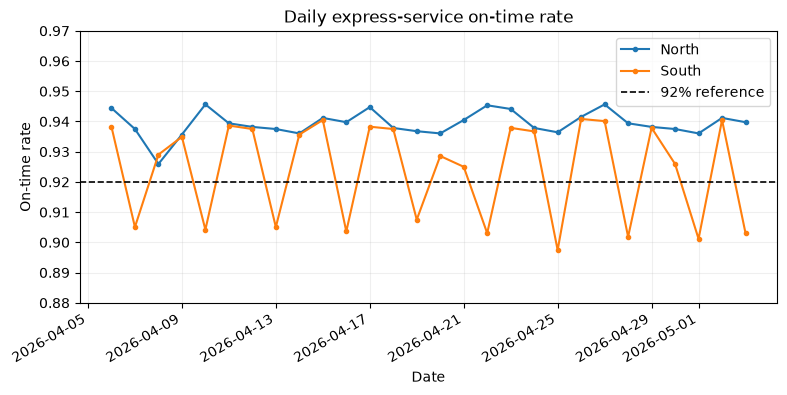

In [54]:
fig_a, ax_a = plt.subplots(figsize=(9, 4))
for region in daily_a.columns:
    ax_a.plot(daily_a.index, daily_a[region], marker="o", markersize=3, label=region)
ax_a.axhline(0.92, color="black", linestyle="--", linewidth=1.2, label="92% reference")
ax_a.set(title="Daily express-service on-time rate", xlabel="Date", ylabel="On-time rate")
ax_a.set_ylim(0.88, 0.97)
ax_a.legend()
ax_a.grid(alpha=0.2)
fig_a.autofmt_xdate()
plt.show()


### Validation — Solution A


In [55]:
EXPECTED_B = pd.DataFrame({
    "region": ["North", "North", "South", "South"],
    "service": ["express", "standard", "express", "standard"],
    "recorded_parcels": [4785, 6604, 4412, 6454],
    "late_parcels": [289, 566, 335, 646],
    "on_time_parcels": [4496, 6038, 4077, 5808],
    "rows": [55, 54, 54, 55],
})
EXPECTED_B["on_time_rate"] = (
    EXPECTED_B["on_time_parcels"] / EXPECTED_B["recorded_parcels"]
)


def validate_parcel_solution(raw, analysis, summary, daily, below, ax):
    assert raw.shape == (224, 6)
    assert list(raw.columns) == [
        "date", "depot_id", "service", "parcels", "late_parcels", "driver_hours"
    ]
    assert len(analysis) == 218
    assert analysis["region"].notna().all()
    assert analysis["on_time_parcels"].between(0, analysis["parcels"]).all()
    actual = summary.sort_values(["region", "service"]).reset_index(drop=True)
    expected = EXPECTED_B.sort_values(["region", "service"]).reset_index(drop=True)
    pd.testing.assert_frame_equal(actual, expected, check_dtype=False, rtol=1e-12)
    assert int(actual["recorded_parcels"].sum()) == 22255
    assert int(actual["late_parcels"].sum()) == 1836
    assert daily.shape == (28, 2)
    assert list(daily.columns) == ["North", "South"]
    values = daily.to_numpy()
    assert not daily.isna().any().any()
    assert np.isfinite(values).all()
    assert ((values >= 0) & (values <= 1)).all()
    assert below.to_dict() == {"North": 0, "South": 10}
    assert len(ax.get_lines()) == 3  # two data lines and the reference
    assert ax.get_xlabel() and ax.get_ylabel() and ax.get_title()
    assert ax.get_legend() is not None
    return "all parcel checks passed"


validate_parcel_solution(
    raw_a, analysis_a, summary_a, daily_a, below_a, ax_a
)


'all parcel checks passed'

North/express is the strongest regional/service combination at about 94.0%; South/standard is the weakest at about 90.0%. The daily express evidence shows no North days below the 92% reference and ten South days below it.


### Solution B — paired wide count tables and an aligned rate matrix


In [ ]:
raw_b = pd.read_csv(
    DATA_PATH,
    dtype={"depot_id": "string"},
    parse_dates=["date"],
    na_values={"parcels": ["not_recorded"]},
)
analysis_b = raw_b.loc[raw_b["parcels"].notna()].copy() #Keep only the rows where parcels is not missing
analysis_b["parcels"] = analysis_b["parcels"].astype(int)
analysis_b = analysis_b.merge(
    depots, on="depot_id", how="left", validate="many_to_one"   # depot_id is the matching key
)
analysis_b["on_time_parcels"] = analysis_b["parcels"] - analysis_b["late_parcels"]


In [ ]:
express_b = analysis_b.loc[analysis_b["service"] == "express"]
# aggregate and reshape in one step
wide_total_b = express_b.pivot_table(
    index="date", columns="region", values="parcels", aggfunc="sum"
).sort_index()
wide_late_b = express_b.pivot_table(
    index="date", columns="region", values="late_parcels", aggfunc="sum"
).sort_index()

daily_b = (wide_total_b - wide_late_b) / wide_total_b
below_b = (daily_b < 0.92).sum()
wide_total_b.head(), wide_late_b.head(), daily_b.head()


(region      North  South
 date                    
 2026-04-06    180    162
 2026-04-07    176    158
 2026-04-08     81    155
 2026-04-09    171    169
 2026-04-10    184    167,
 region      North  South
 date                    
 2026-04-06     10     10
 2026-04-07     11     15
 2026-04-08      6     11
 2026-04-09     11     11
 2026-04-10     10     16,
 region         North     South
 date                          
 2026-04-06  0.944444  0.938272
 2026-04-07  0.937500  0.905063
 2026-04-08  0.925926  0.929032
 2026-04-09  0.935673  0.934911
 2026-04-10  0.945652  0.904192)

In [ ]:
count_totals_b = analysis_b.pivot_table(
    index=["region", "service"],
    values=["parcels", "late_parcels", "on_time_parcels"],
    aggfunc="sum",
)
# how many observations there are in each region–service combination
row_counts_b = analysis_b.groupby(["region", "service"])["parcels"].size()

summary_b = (
    count_totals_b.rename(columns={"parcels": "recorded_parcels"})
    .assign(rows=row_counts_b)  # pandas aligns the shared index labels
    .reset_index()
)
summary_b["on_time_rate"] = (
    summary_b["on_time_parcels"] / summary_b["recorded_parcels"]
)
summary_b = summary_b[
    ["region", "service", "recorded_parcels", "late_parcels",
     "on_time_parcels", "rows", "on_time_rate"]
]
summary_b


,region,service,recorded_parcels,late_parcels,on_time_parcels,rows,on_time_rate
0,North,express,4785,289,4496,55,0.939603
1,North,standard,6604,566,6038,54,0.914294
2,South,express,4412,335,4077,54,0.924071
3,South,standard,6454,646,5808,55,0.899907


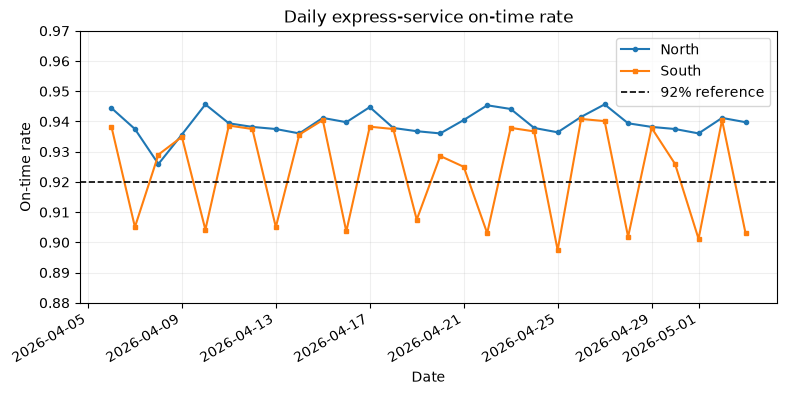

In [59]:
fig_b, ax_b = plt.subplots(figsize=(9, 4))
ax_b.plot(daily_b.index, daily_b["North"], marker="o", markersize=3, label="North")
ax_b.plot(daily_b.index, daily_b["South"], marker="s", markersize=3, label="South")
ax_b.axhline(0.92, color="black", linestyle="--", linewidth=1.2, label="92% reference")
ax_b.set(title="Daily express-service on-time rate", xlabel="Date", ylabel="On-time rate")
ax_b.set_ylim(0.88, 0.97)
ax_b.legend()
ax_b.grid(alpha=0.2)
fig_b.autofmt_xdate()
plt.show()


### Validation — Solution B


In [60]:
validate_parcel_solution(
    raw_b, analysis_b, summary_b, daily_b, below_b, ax_b
)
pd.testing.assert_frame_equal(daily_a, daily_b)
pd.testing.assert_frame_equal(
    summary_a.sort_values(["region", "service"]).reset_index(drop=True),
    summary_b.sort_values(["region", "service"]).reset_index(drop=True),
    check_dtype=False,
)


### Comparing the two approaches

- **Long-format workflow**:\
keeps the cleaned row-level dataset as the main working table. The data are cleaned, merged, grouped, and checked in a sequence that remains close to the original observations.\
The reliability rate is calculated in a grouped summary, and the data are reshaped into date-by-region form only at the end.

- **Paired wide tables**:\
build separate date-by-region tables for total parcels and late parcels. This makes the daily calculation easy to see because the two tables have the same dates and regions and can be compared directly.\
However, the separate region-by-service summary still needs to be produced with its own aggregation step.

- **Both approaches are valid in an exam.**\
In both cases, the important points are to check the depot-to-region merge, sum parcel counts before calculating rates, keep the dates in chronological order, and verify the final daily table.\
The better choice is the one you can implement, explain, and check most confidently under time pressure.